# 02 · Segmentación por ciclo de vida financiero

**Caso de uso 5** · **Sector:** Banca · **Analítica:** Clustering · **Solo ACH:** Sí
**Metodología:** CRISP-DM · Fases 3–4 · **Depende de:** `00_EDA_Preparacion_Datos.ipynb`

### Objetivo de negocio
Ubicar a cada persona en su **etapa de vida financiera** — informal emergente, asalariado formal, consolidado
que ahorra para pensión, independiente, pensionado, o en deterioro — para orientar el producto: una AFP o
aseguradora busca al que **cotiza pensión**; un banco de crédito, al asalariado en crecimiento o al endeudado.

**Empresas objetivo:** Bancolombia, Davivienda, Banco de Bogotá, Banco Caja Social,
**Porvenir AFP, Protección AFP, Skandia, Sura**.

### Novedades de esta iteración
- **Llave por cédula** → cruza las 3 fuentes limpiamente (el enriquecimiento transaccional ya no es aproximado).
- **Clasificación de personas** de Seguridad Social (empleado / independiente / pensionado / aprendiz) entra
  como feature → segmentos más específicos y directamente accionables.
- **Ahorro y deuda sin cuenta propia** (flujo neto real).

> ⚠️ Sin fecha de nacimiento, la "etapa" se infiere del **comportamiento financiero**, no de la edad.

## 1 · Configuración

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

ROOT = Path.cwd()
if not (ROOT / "scripts").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))
import ach_pipeline as ap   # noqa: E402

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (11, 4.2),
                     "axes.titlesize": 12, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
RNG = 0
print("Listo")

Listo


## 2 · Construcción de features (nivel persona)

`ap.build_lifecycle_features()` combina la clasificación de personas de Seguridad Social (tipo, prestaciones,
ingreso y su dinámica) con el enriquecimiento transaccional (ahorro, deuda).

In [2]:
lc = ap.build_lifecycle_features()
print(f"Personas (universo Seguridad Social): {len(lc):,}")
print(f"Con enriquecimiento transaccional (cédula): {lc['tiene_transaccional'].mean()*100:.1f}%")
lc["is_indep"] = (lc["tipo_persona"] == "Independiente").astype(int)
lc["is_pens"] = (lc["tipo_persona"] == "Pensionado").astype(int)
feat_cluster = ["ibc_ss", "ibc_volatilidad", "frac_pension", "frac_riesgos",
                "ibc_tendencia", "n_meses_ss", "is_indep", "is_pens"]
display(lc[feat_cluster + ["flujo_neto_mensual", "gasto_financiero_share"]]
        .describe(percentiles=[.25, .5, .75, .95]).T)

Personas (universo Seguridad Social): 33,281
Con enriquecimiento transaccional (cédula): 73.8%


,count,mean,std,min,25%,50%,75%,95%,max
ibc_ss,"33,281.000","1,732,054.705","2,411,029.924",0.000,"437,726.000","1,423,500.000","1,813,234.000","5,271,383.000","35,587,500.000"
ibc_volatilidad,"33,281.000",0.245,0.266,0.000,0.000,0.194,0.358,0.742,3.479
frac_pension,"33,281.000",0.158,0.330,0.000,0.000,0.000,0.000,1.000,1.000
frac_riesgos,"33,281.000",0.436,0.425,0.000,0.000,0.333,0.976,1.000,1.000
ibc_tendencia,"33,281.000",0.014,0.107,-1.359,0.000,0.005,0.023,0.121,1.371
n_meses_ss,"33,281.000",19.922,12.761,1.000,7.000,20.000,34.000,36.000,36.000
is_indep,"33,281.000",0.094,0.292,0.000,0.000,0.000,0.000,1.000,1.000
is_pens,"33,281.000",0.010,0.099,0.000,0.000,0.000,0.000,0.000,1.000
flujo_neto_mensual,"33,281.000","478,809.016","2,330,949.231","-21,445,093.556",0.000,0.000,"286,462.778","2,725,146.784","281,972,134.722"
gasto_financiero_share,"33,281.000",0.179,0.275,0.000,0.000,0.000,0.304,0.806,1.000


### 2.1 · Distribuciones clave

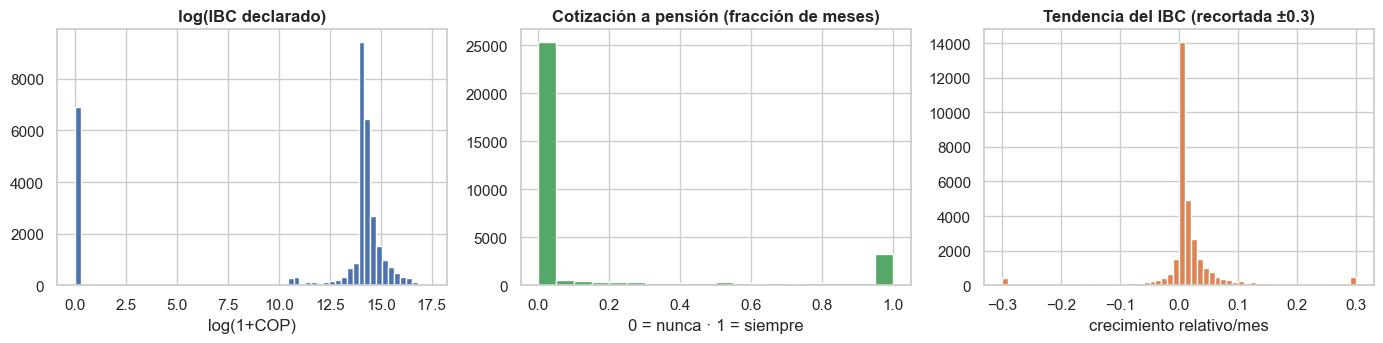

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
axes[0].hist(np.log1p(lc["ibc_ss"].clip(lower=0)), bins=60, color="#4c72b0", edgecolor="white")
axes[0].set_title("log(IBC declarado)"); axes[0].set_xlabel("log(1+COP)")
axes[1].hist(lc["frac_pension"], bins=20, color="#55a868", edgecolor="white")
axes[1].set_title("Cotización a pensión (fracción de meses)"); axes[1].set_xlabel("0 = nunca · 1 = siempre")
axes[2].hist(lc["ibc_tendencia"].clip(-0.3, 0.3), bins=60, color="#dd8452", edgecolor="white")
axes[2].set_title("Tendencia del IBC (recortada ±0.3)"); axes[2].set_xlabel("crecimiento relativo/mes")
plt.tight_layout(); plt.show()

## 3 · Preprocesamiento
El clustering usa las señales de Seguridad Social (nivel, dinámica, formalidad y **tipo de persona**). El
ahorro y la deuda del enriquecimiento se reservan para **perfilar** los segmentos (cobertura parcial).

In [4]:
Y = lc[feat_cluster].copy()
Y["ibc_ss"] = np.log1p(Y["ibc_ss"].clip(lower=0))
Ys = StandardScaler().fit_transform(Y.fillna(0.0))
print("Matriz de modelado:", Ys.shape)

Matriz de modelado: (33281, 8)


## 4 · Selección del número de segmentos (k)

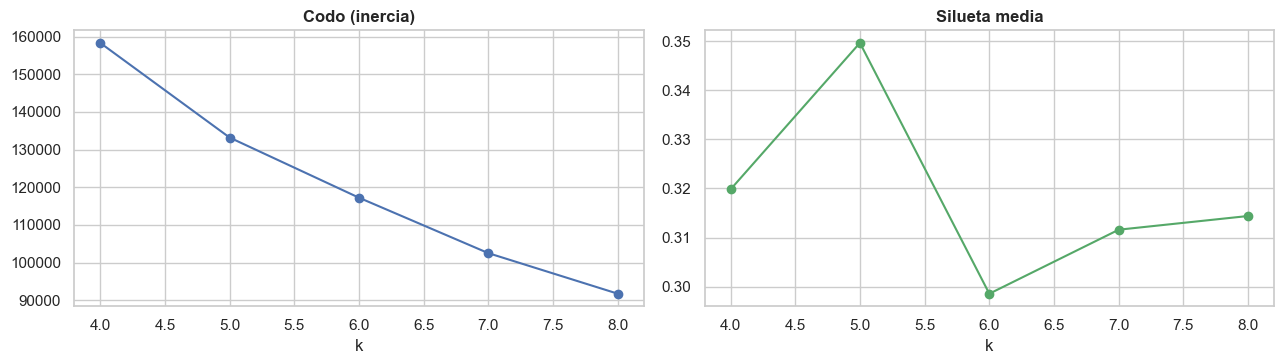

k con mejor silueta (k>=4): 5  (silueta = 0.350)


In [5]:
ks = range(4, 9)
inercia, sil = [], []
muestra = np.random.RandomState(RNG).choice(len(Ys), min(8000, len(Ys)), replace=False)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RNG).fit(Ys)
    inercia.append(km.inertia_); sil.append(silhouette_score(Ys[muestra], km.labels_[muestra]))
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].plot(list(ks), inercia, "o-", color="#4c72b0"); axes[0].set_title("Codo (inercia)"); axes[0].set_xlabel("k")
axes[1].plot(list(ks), sil, "o-", color="#55a868"); axes[1].set_title("Silueta media"); axes[1].set_xlabel("k")
plt.tight_layout(); plt.show()
K = list(ks)[int(np.argmax(sil))]
print(f"k con mejor silueta (k>=4): {K}  (silueta = {max(sil):.3f})")

## 5 · Segmentación final (K-Means)

In [6]:
km = KMeans(n_clusters=K, n_init=20, random_state=RNG).fit(Ys)
lc["cluster"] = km.labels_
perfil = lc.groupby("cluster").agg(
    personas=("person_id", "size"), ibc=("ibc_ss", "median"),
    frac_pension=("frac_pension", "median"), frac_riesgos=("frac_riesgos", "median"),
    tendencia=("ibc_tendencia", "median"), volatilidad=("ibc_volatilidad", "median"),
    indep=("is_indep", "mean"), pens=("is_pens", "mean"), meses=("n_meses_ss", "median"))
display(perfil.round(3))

,personas,ibc,frac_pension,frac_riesgos,tendencia,volatilidad,indep,pens,meses
cluster,,,,,,,,,
0,5897,0.000,0.000,1.000,0.000,0.000,0.000,0.000,11.000
1,19635,"1,501,159.000",0.000,0.133,0.012,0.272,0.000,0.000,22.000
2,330,"1,300,000.000",0.000,0.000,0.011,0.130,0.000,1.000,29.000
3,3123,"1,423,500.000",0.000,0.105,0.009,0.180,1.000,0.000,14.000
4,4296,"1,563,416.500",1.000,0.857,0.007,0.193,0.000,0.000,31.000


### 5.1 · Nombres de etapa financiera
Regla sobre el perfil: pensionados, independientes, formal que cotiza pensión, base sin ingreso salud, y
asalariado formal (salud sin pensión).

In [7]:
def nombrar(r):
    if r["pens"] >= 0.5:
        return "Pensionados"
    if r["indep"] >= 0.5:
        return "Independientes"
    if r["frac_pension"] >= 0.5:
        return "Formal consolidado (cotiza pensión)"
    if r["ibc"] < 100_000:
        return "Base sin ingreso salud declarado"
    if r["volatilidad"] >= 0.5 and r["tendencia"] < 0:
        return "Ingreso volátil en deterioro"
    return "Asalariado formal (salud sin pensión)"

nombres = {cl: nombrar(perfil.loc[cl]) for cl in perfil.index}
vistos = {}
for cl in perfil.sort_values("ibc", ascending=False).index:
    n = nombres[cl]
    if n in vistos.values():
        n = f"{n} ({perfil.loc[cl, 'personas']:,})"
    vistos[cl] = n
lc["etapa"] = lc["cluster"].map(vistos)
perfil["etapa"] = perfil.index.map(vistos)
display(perfil.set_index("etapa").round(3))

,personas,ibc,frac_pension,frac_riesgos,tendencia,volatilidad,indep,pens,meses
etapa,,,,,,,,,
Base sin ingreso salud declarado,5897,0.000,0.000,1.000,0.000,0.000,0.000,0.000,11.000
Asalariado formal (salud sin pensión),19635,"1,501,159.000",0.000,0.133,0.012,0.272,0.000,0.000,22.000
Pensionados,330,"1,300,000.000",0.000,0.000,0.011,0.130,0.000,1.000,29.000
Independientes,3123,"1,423,500.000",0.000,0.105,0.009,0.180,1.000,0.000,14.000
Formal consolidado (cotiza pensión),4296,"1,563,416.500",1.000,0.857,0.007,0.193,0.000,0.000,31.000


## 6 · Visualización

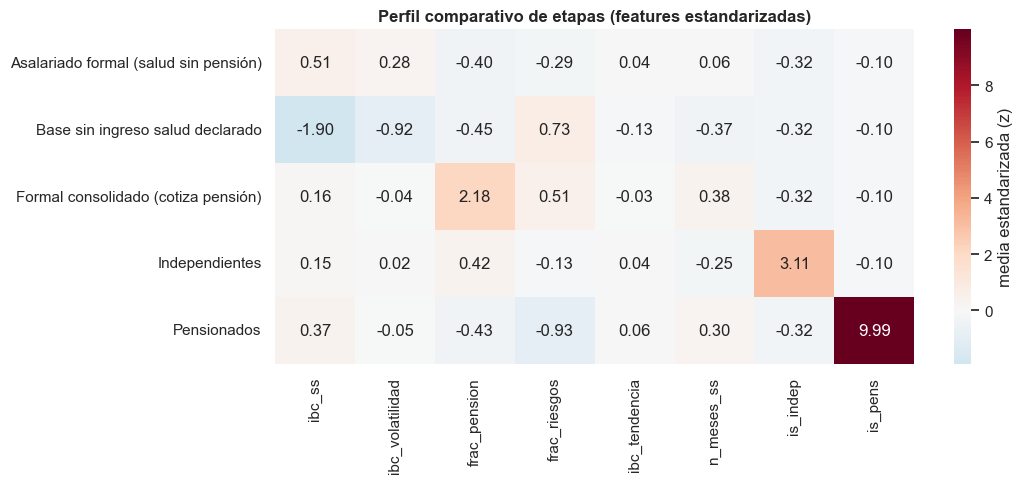

In [8]:
Ystd = pd.DataFrame(Ys, columns=feat_cluster); Ystd["etapa"] = lc["etapa"].values
heat = Ystd.groupby("etapa").mean()
fig, ax = plt.subplots(figsize=(11, 0.7 * len(heat) + 1.5))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "media estandarizada (z)"})
ax.set_title("Perfil comparativo de etapas (features estandarizadas)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

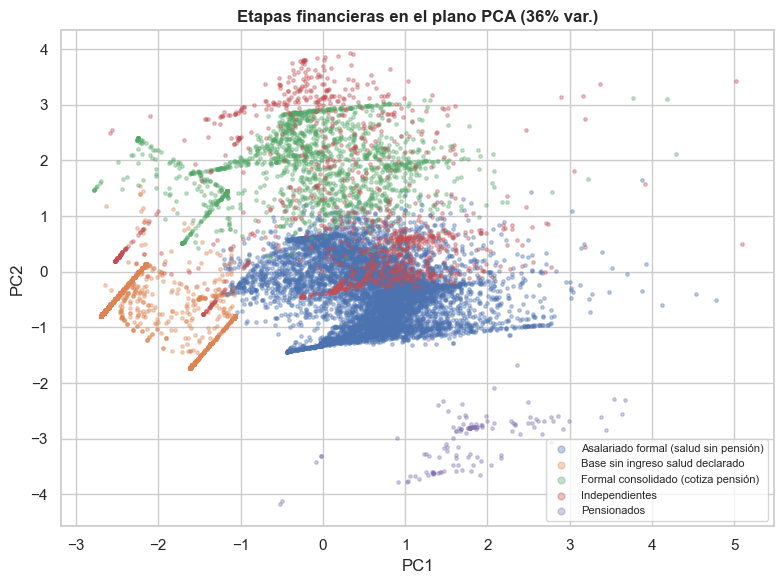

In [9]:
pca = PCA(n_components=2, random_state=RNG).fit(Ys); proj = pca.transform(Ys)
idx = np.random.RandomState(RNG).choice(len(proj), min(12000, len(proj)), replace=False)
fig, ax = plt.subplots(figsize=(8, 6))
for seg in sorted(lc["etapa"].unique()):
    m = (lc["etapa"].values == seg)[idx]
    ax.scatter(proj[idx][m, 0], proj[idx][m, 1], s=6, alpha=.35, label=seg)
ax.set_title(f"Etapas financieras en el plano PCA ({pca.explained_variance_ratio_.sum():.0%} var.)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(markerscale=2, fontsize=8)
plt.tight_layout(); plt.show()

## 7 · Perfilamiento transaccional: ahorro y deuda por etapa
Sobre las personas que cruzan con lo transaccional: capacidad de ahorro (flujo neto mensual) y carga de deuda
(gasto financiero sobre PSE).

,personas,flujo_neto_mensual,carga_deuda
etapa,,,
Asalariado formal (salud sin pensión),15384,"67,735.700",0.090
Base sin ingreso salud declarado,4035,"54,000.000",0.100
Formal consolidado (cotiza pensión),2586,"23,687.880",0.180
Independientes,2311,"91,698.000",0.050
Pensionados,237,"109,126.440",0.090


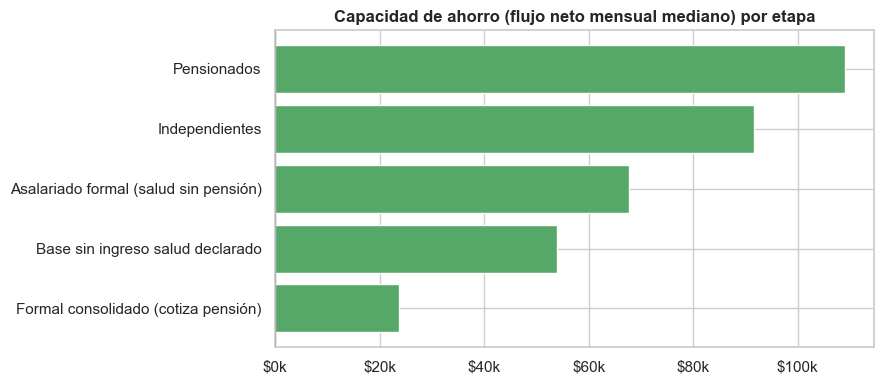

In [10]:
enr = lc[lc["tiene_transaccional"]]
perfil_tx = enr.groupby("etapa").agg(
    personas=("person_id", "size"),
    flujo_neto_mensual=("flujo_neto_mensual", "median"),
    carga_deuda=("gasto_financiero_share", "median"))
display(perfil_tx.round(2))
fig, ax = plt.subplots(figsize=(9, 4)); p = perfil_tx.sort_values("flujo_neto_mensual")
ax.barh(p.index, p["flujo_neto_mensual"],
        color=["#c44e52" if v < 0 else "#55a868" for v in p["flujo_neto_mensual"]])
ax.axvline(0, color="k", lw=.8); ax.set_title("Capacidad de ahorro (flujo neto mensual mediano) por etapa")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:,.0f}k"))
plt.tight_layout(); plt.show()

## 8 · Lectura por cliente objetivo y conclusiones

| Etapa | Quién la compraría | Acción |
|---|---|---|
| **Formal consolidado (cotiza pensión)** | **AFP / aseguradora** (Porvenir, Protección, Skandia, Sura) | Aporte voluntario a pensión, inversión, seguros de vida |
| **Independientes** | Banco + AFP | Formalización del ahorro pensional, crédito de ingreso variable |
| **Asalariado formal (salud sin pensión)** | Banco + AFP | Activar pensión; crédito de consumo/vivienda |
| **Pensionados** | Banco + aseguradora | Productos de renta, salud, bajo riesgo |
| **Base sin ingreso salud declarado** | Inclusión financiera | Bancarización, microproductos |

**Próximos pasos:** con la re-extracción de llave hasheada el cruce deja de asumir riesgo de colisión; sumar
edad convierte la "etapa inferida" en ciclo de vida real; combinar con el modelo de valor (matriz etapa × valor).

In [11]:
sal = ROOT / "Data" / "processed" / "segmentos_ciclo_vida.parquet"
lc[["person_id", "cluster", "etapa", "tipo_persona", "ibc_ss", "frac_pension",
    "ibc_tendencia", "tiene_transaccional"]].to_parquet(sal, index=False)
print("Guardado:", sal)

Guardado: C:\Users\geoff\Desktop\Proyecto IA ACH\Data\processed\segmentos_ciclo_vida.parquet
